Rows: 973

Top tokens per segment:
Segment 1 → ['love', 'fast', 'really', 'school', 'lightweight', 'use', 'new', 'well', 'recommend', 'works']
Segment 2 → ['great', 'like', 'good', 'fast', 'works', 'perfect', 'toshiba', 'excellent', 'laptopthank', 'light']
Segment 3 → ['not', 'gb', 'screen', 'keyboard', 'good', 'use', 'like', 'only', 'usb', 'ssd']
Segment 4 → ['not', 'no', 'would', 'all', 'use', 'just', 'machine', 'screen', 'time', 'back']


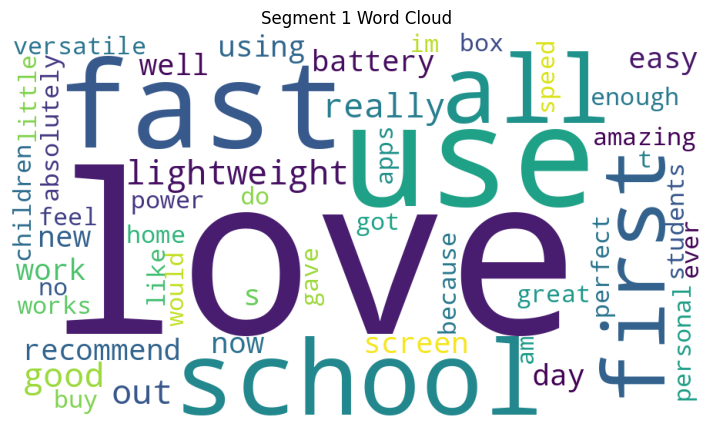

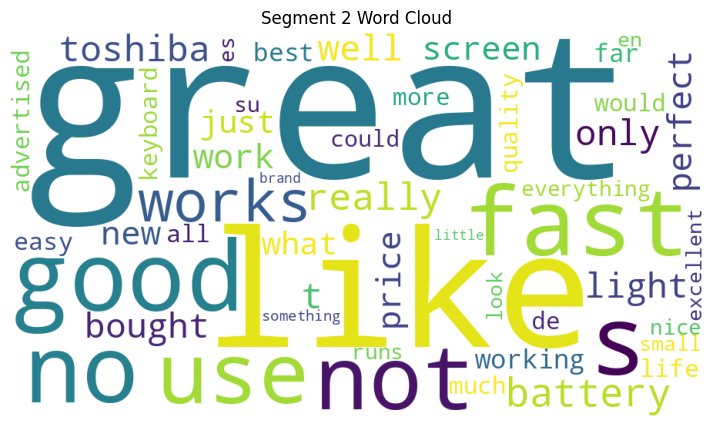

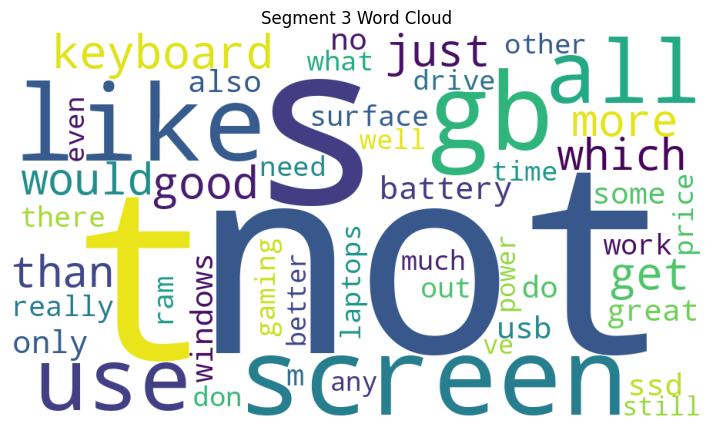

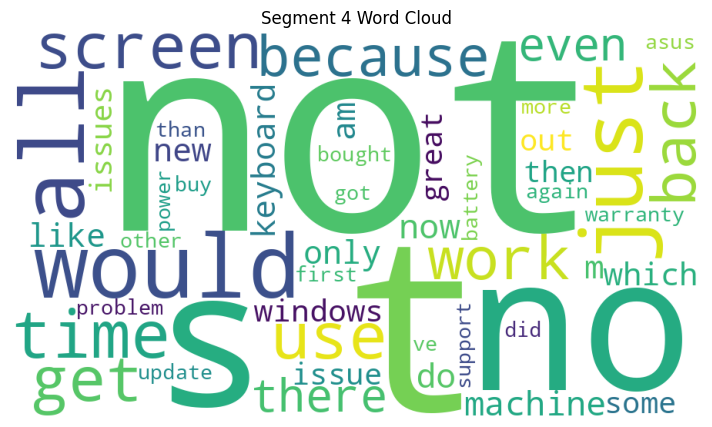

In [ ]:
import pandas as pd
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# LOAD

df = pd.read_csv("correct_laptop_reviews.csv")

print("Rows:", len(df))



# CLEAN TEXT (STOPWORDS REMOVED HERE)

custom_stopwords = {
"a","an","the","and","or","but","so","if","while","of","in","on","at","by","from","about","as","to","for",
"with","very","have","has","had","can","will","after","when","one","up",
"is","are","was","were","be","been","being","this","that","these","those","it","its","they","them",
"their","he","she","his","her","we","our","you","your","i","me","my",
"laptop","product","computer"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [w for w in text.split() if w not in custom_stopwords]
    return " ".join(tokens)

df["clean_text"] = df["review_text"].apply(clean_text)



# SEGMENTATION (TF-IDF + KMEANS)

vectorizer = TfidfVectorizer(max_features=3000)

X = vectorizer.fit_transform(df["clean_text"])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df["segment"] = kmeans.fit_predict(X) + 1



# TOP TOKENS PER SEGMENT

terms = vectorizer.get_feature_names_out()
centroids = kmeans.cluster_centers_

print("\nTop tokens per segment:")
for i, center in enumerate(centroids):
    top_idx = center.argsort()[-10:][::-1]
    words = [terms[j] for j in top_idx]
    print(f"Segment {i+1} → {words}")



# WORD CLOUD PER SEGMENT

for seg in sorted(df["segment"].unique()):

    text_blob = " ".join(df[df["segment"] == seg]["clean_text"])

    words = text_blob.split()
    freq = Counter(words)

    # minimum frequency = 2
    freq = {w: c for w, c in freq.items() if c >= 2}

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        max_words=50
    ).generate_from_frequencies(freq)

    plt.figure(figsize=(10,5))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Segment {seg} Word Cloud")
    plt.show()

    # optional save
    wc.to_file(f"segment_{seg}_wordcloud.png")



# SAVE SEGMENTED DATA

df.to_csv("segmented_output.csv", index=False)

In [ ]:

# SENTIMENT ANALYSIS (AFTER segmentation)

from afinn import Afinn

afinn = Afinn()

df["sentiment_score"] = df["clean_text"].apply(afinn.score)

def label(score):
    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    else:
        return "neutral"

df["sentiment_label"] = df["sentiment_score"].apply(label)



# SENTIMENT PER SEGMENT

sentiment_by_segment = (
    df.groupby("segment")
      .agg(
          avg_sentiment=("sentiment_score", "mean"),
          positive_pct=("sentiment_label", lambda x: (x=="positive").mean()*100),
          neutral_pct=("sentiment_label", lambda x: (x=="neutral").mean()*100),
          negative_pct=("sentiment_label", lambda x: (x=="negative").mean()*100),
          reviews=("segment","count")
      )
      .round(2)
)

print("\nSentiment analysis per segment:")
print(sentiment_by_segment)


Sentiment analysis per segment:
         avg_sentiment  positive_pct  neutral_pct  negative_pct  reviews
segment                                                                 
1                 6.34        100.00         0.00          0.00       29
2                 4.42         75.43        11.21         13.36      232
3                22.15         90.33         1.33          8.33      300
4                 2.16         49.03         8.50         42.48      412
